In [23]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
# import deeplabcut

In [24]:
data = pd.read_csv('./churn.txt')

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   State           3333 non-null   object 
 1   Account Length  3333 non-null   int64  
 2   Area Code       3333 non-null   int64  
 3   Phone           3333 non-null   object 
 4   Int'l Plan      3333 non-null   object 
 5   VMail Plan      3333 non-null   object 
 6   VMail Message   3333 non-null   int64  
 7   Day Mins        3333 non-null   float64
 8   Day Calls       3333 non-null   int64  
 9   Day Charge      3333 non-null   float64
 10  Eve Mins        3333 non-null   float64
 11  Eve Calls       3333 non-null   int64  
 12  Eve Charge      3333 non-null   float64
 13  Night Mins      3333 non-null   float64
 14  Night Calls     3333 non-null   int64  
 15  Night Charge    3333 non-null   float64
 16  Intl Mins       3333 non-null   float64
 17  Intl Calls      3333 non-null   i

In [26]:
data.head()

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


In [27]:
from sklearn.preprocessing import LabelEncoder

lb_make = LabelEncoder()
data["Churn_code"] = lb_make.fit_transform(data["Churn?"])
data["Int_Plan"] = lb_make.fit_transform(data['Int\'l Plan'])
data['VMail_Plan'] =lb_make.fit_transform(data['VMail Plan'])
data.head()

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?,Churn_code,Int_Plan,VMail_Plan
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,91,11.01,10.0,3,2.70,1,False.,0,0,1
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,11.45,13.7,3,3.70,1,False.,0,0,1
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,104,7.32,12.2,5,3.29,0,False.,0,0,0
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,89,8.86,6.6,7,1.78,2,False.,0,1,0
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,121,8.41,10.1,3,2.73,3,False.,0,1,0


In [28]:
data = data.drop(data[['Int\'l Plan', 'VMail Plan', 'Churn?']], axis=1)
data.reset_index(drop=True, inplace=True)

In [29]:
data.head()

,State,Account Length,Area Code,Phone,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,...,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn_code,Int_Plan,VMail_Plan
0,KS,128,415,382-4657,25,265.1,110,45.07,197.4,99,...,244.7,91,11.01,10.0,3,2.70,1,0,0,1
1,OH,107,415,371-7191,26,161.6,123,27.47,195.5,103,...,254.4,103,11.45,13.7,3,3.70,1,0,0,1
2,NJ,137,415,358-1921,0,243.4,114,41.38,121.2,110,...,162.6,104,7.32,12.2,5,3.29,0,0,0,0
3,OH,84,408,375-9999,0,299.4,71,50.90,61.9,88,...,196.9,89,8.86,6.6,7,1.78,2,0,1,0
4,OK,75,415,330-6626,0,166.7,113,28.34,148.3,122,...,186.9,121,8.41,10.1,3,2.73,3,0,1,0


In [30]:
# get a list of columns
cols = list(data)
# move the column to head of list using index, pop and insert
cols.insert(0, cols.pop(cols.index('Churn_code')))
# cols
# # use ix to reorder
data = data.loc[:, cols]
data.head()

,Churn_code,State,Account Length,Area Code,Phone,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,...,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Int_Plan,VMail_Plan
0,0,KS,128,415,382-4657,25,265.1,110,45.07,197.4,...,16.78,244.7,91,11.01,10.0,3,2.70,1,0,1
1,0,OH,107,415,371-7191,26,161.6,123,27.47,195.5,...,16.62,254.4,103,11.45,13.7,3,3.70,1,0,1
2,0,NJ,137,415,358-1921,0,243.4,114,41.38,121.2,...,10.30,162.6,104,7.32,12.2,5,3.29,0,0,0
3,0,OH,84,408,375-9999,0,299.4,71,50.90,61.9,...,5.26,196.9,89,8.86,6.6,7,1.78,2,1,0
4,0,OK,75,415,330-6626,0,166.7,113,28.34,148.3,...,12.61,186.9,121,8.41,10.1,3,2.73,3,1,0


In [ ]:
X = data.iloc[:,5:]
Y = data.iloc[:,0]

In [34]:
X.head()

,Phone,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Int_Plan,VMail_Plan
0,382-4657,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0,1
1,371-7191,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0,1
2,358-1921,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0,0
3,375-9999,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,1,0
4,330-6626,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,1,0


In [32]:
bestfeatures = SelectKBest(score_func=chi2, k=5)

In [33]:
fit = bestfeatures.fit(X, Y)

ValueError: could not convert string to float: '382-4657'

In [ ]:
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)

In [ ]:
#concat two dataframes for better visualization 

featureScores = pd.concat([dfcolumns, dfscores], axis=1)

In [ ]:
featureScores.columns = ['Spec', 'Score']

In [ ]:
featureScores.groupby(sorted(featureScores.Score))

In [ ]:
print(featureScores.nlargest(5,'Score'))

             Spec        Score
2        Day Mins  2314.169315
1   VMail Message   620.628799
4      Day Charge   393.399658
5        Eve Mins   367.164781
15       Int_Plan   203.244178


In [ ]:
# Feature importance gives you a score for each feature of your data, the higher the score more important or relevant is the feature towards your output variable.

from sklearn.ensemble import ExtraTreesClassifier
import matplotlib.pyplot as plt

In [ ]:
model = ExtraTreesClassifier()
model.fit(X, Y)
#use inbuilt class feature_importances of tree based classifiers
print(model.feature_importances_)

[0.03585944 0.01738346 0.12467565 0.03739525 0.13655791 0.05945672
 0.03538148 0.05956018 0.04065582 0.03508249 0.04172301 0.04812862
 0.05781131 0.04979252 0.12824543 0.07280912 0.01948158]


In [ ]:
dfscores1 = pd.DataFrame(model.feature_importances_)
dfcolumns1 = pd.DataFrame(X.columns)

In [ ]:
#concat two dataframes for better visualization 

featureimp = pd.concat([dfcolumns1, dfscores1], axis=1)
featureimp = pd.DataFrame(featureimp)

In [ ]:
featureimp.shape

(17, 2)

In [ ]:
featureimp.columns = ['Spec','feature_Imp']

In [ ]:
featureimp

,Spec,feature_Imp
0,Account Length,0.035859
1,VMail Message,0.017383
2,Day Mins,0.124676
3,Day Calls,0.037395
4,Day Charge,0.136558
5,Eve Mins,0.059457
6,Eve Calls,0.035381
7,Eve Charge,0.059560
8,Night Mins,0.040656
9,Night Calls,0.035082


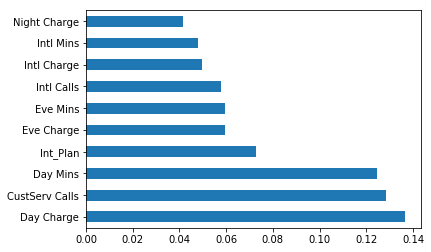

In [ ]:
#plot graph of feature importances for better visualization

feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

In [ ]:
feature_selection = feat_importances.nlargest(5)

In [ ]:
col = feature_selection.keys()
feature = data[col]

In [ ]:
feature.head()

,Day Charge,CustServ Calls,Day Mins,Int_Plan,Eve Charge
0,45.07,1,265.1,0,16.78
1,27.47,1,161.6,0,16.62
2,41.38,0,243.4,0,10.30
3,50.90,2,299.4,1,5.26
4,28.34,3,166.7,1,12.61


In [ ]:
# feature['Target'] = data['Churn_code']

In [ ]:
feature.head()

,Day Charge,CustServ Calls,Day Mins,Int_Plan,Eve Charge
0,45.07,1,265.1,0,16.78
1,27.47,1,161.6,0,16.62
2,41.38,0,243.4,0,10.30
3,50.90,2,299.4,1,5.26
4,28.34,3,166.7,1,12.61


In [ ]:
# feature.to_excel('./churn_cleaned.xlsx', index=None)

In [ ]:
feature.isna().sum()

Day Charge        0
CustServ Calls    0
Day Mins          0
Int_Plan          0
Eve Charge        0
dtype: int64

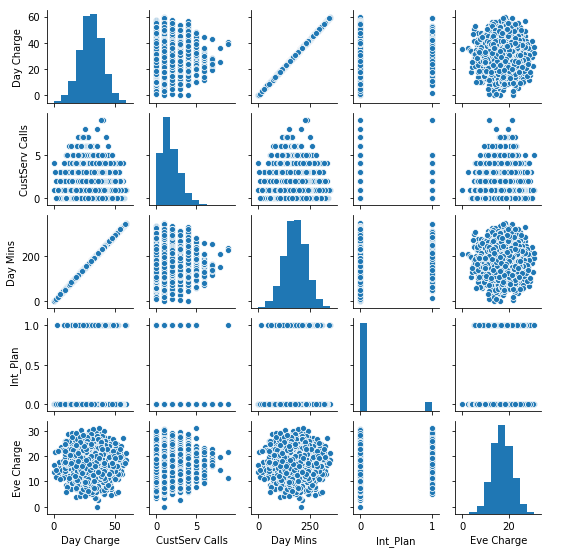

In [ ]:
sns.pairplot(feature, height=1.5)

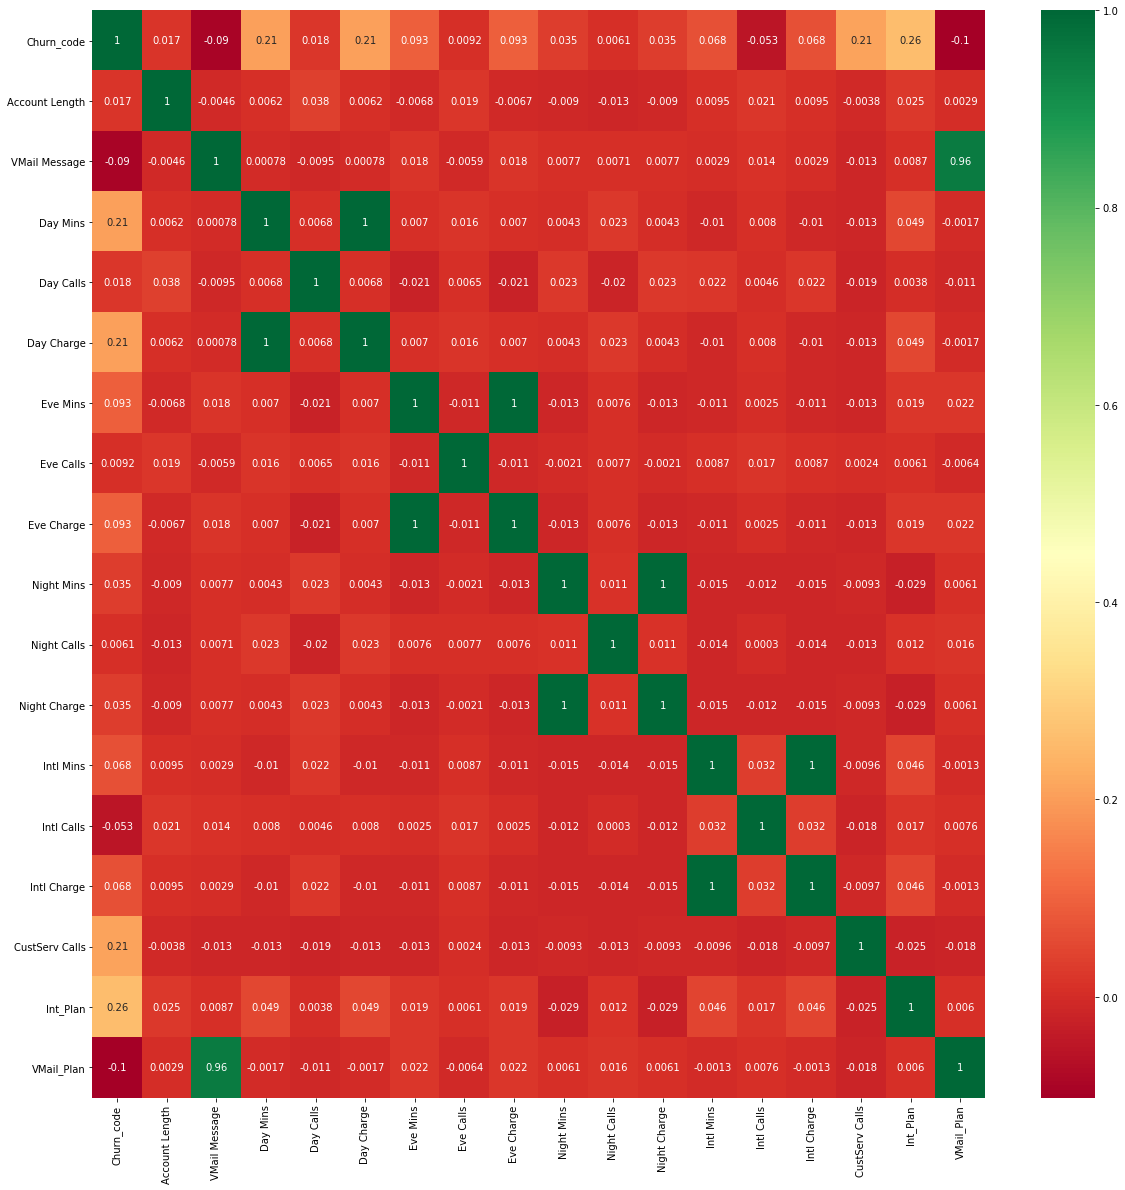

In [ ]:
#get correlations of each features in dataset
import seaborn as sns
corrmat = data.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(20,20))
#plot heat map
g=sns.heatmap(data[top_corr_features].corr(),annot=True,cmap="RdYlGn")

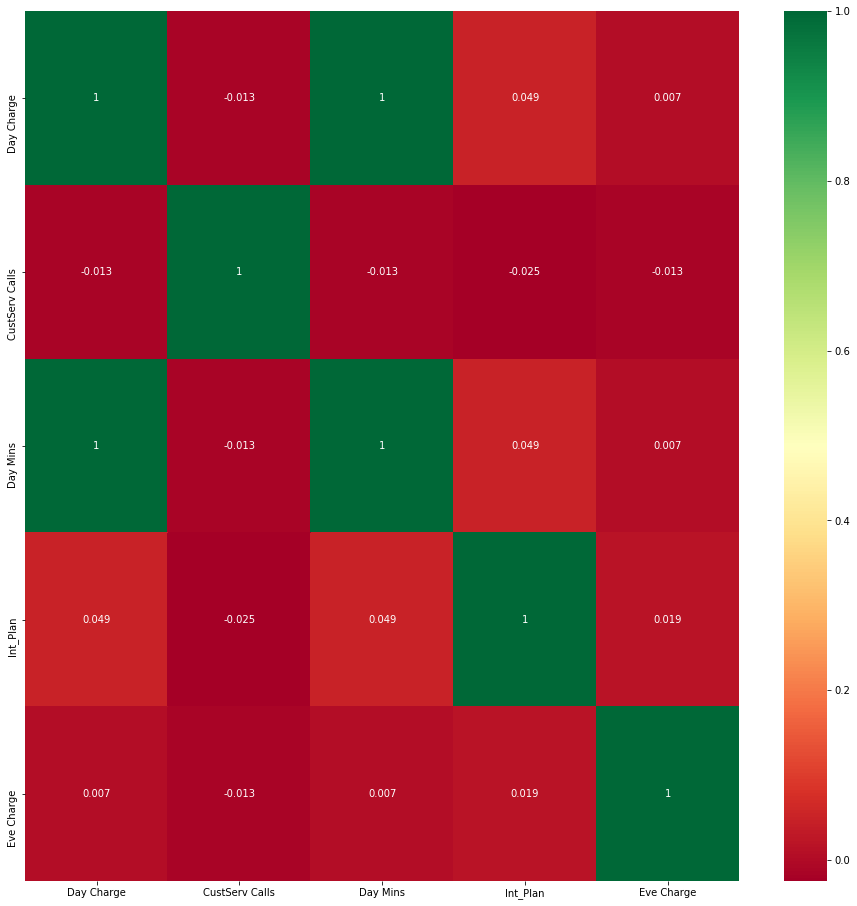

In [ ]:
#get correlations of each features in dataset
import seaborn as sns
corrmat = data.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(16,16))
#plot heat map
g=sns.heatmap(feature.corr(),annot=True,cmap="RdYlGn")

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(feature.values, Y.values, test_size=0.2, random_state=42)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(2666, 5)
(667, 5)
(2666,)
(667,)


In [ ]:
x_test

array([[ 26.35,   1.  , 155.  ,   0.  ,  28.1 ],
       [ 18.55,   0.  , 109.1 ,   0.  ,  18.48],
       [  0.  ,   4.  ,   0.  ,   0.  ,  13.57],
       ...,
       [ 26.98,   1.  , 158.7 ,   0.  ,  13.64],
       [ 19.98,   3.  , 117.5 ,   0.  ,  17.58],
       [ 27.91,   1.  , 164.2 ,   0.  ,  13.21]])

In [ ]:
#clf_gini = DecisionTreeClassifier() 
clf_gini =  DecisionTreeClassifier(criterion = "gini", random_state = 100,max_depth = 200, min_samples_leaf = 8) 
#clf_gini =  DecisionTreeClassifier(criterion = "entropy", random_state = 100,max_depth = 200, min_samples_leaf = 8) 

In [ ]:
clf_gini.fit(x_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=200, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=8, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=100, splitter='best')

In [ ]:
y_pred = clf_gini.predict(x_test)

In [ ]:
print("Accuracy of our model prediction:{}".format(accuracy_score(y_test, y_pred)))

Accuracy of our model prediction:0.9010494752623688


[[537  29]
 [ 37  64]]


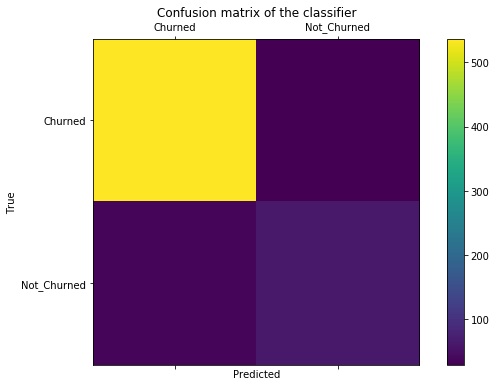

In [ ]:
from sklearn.metrics import confusion_matrix
labels = ['Churned', 'Not_Churned']
cm = confusion_matrix(y_test, y_pred)
print(cm)
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111)
cax = ax.matshow(cm)
plt.title('Confusion matrix of the classifier')
fig.colorbar(cax)
ax.set_xticklabels([''] + labels)
ax.set_yticklabels([''] + labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
x_test1 = np.array([[200, 2, 10, 5, 15]])
# y_pred1 = clf_gini.predict(x_test1)
x_test1

array([[200,   2,  10,   5,  15]])

In [ ]:
from flask import Flask, jsonify, request
from flasgger import Swagger
import pickle
with open('./churn.pkl', 'wb') as model_churn:
    pickle.dump(clf_gini, model_churn, protocol=2)

In [ ]:
with open('./churn.pkl', 'rb') as model_file:
    model = pickle.load(model_file)

In [ ]:
app = Flask(__name__)
swagger= Swagger(app)

In [ ]:
@app.route("/predict_get", methods=['GET'])
def predict_churn():
    
    """Example endpoint returning a prediction of Telecom Churn
    ---
    parameters:
      - name: Day_Mins
        in: query
        type: number
        required: true
      - name: CustServ_Calls
        in: query
        type: number
        required: true
      - name: Day_Charge
        in: query
        type: number
        required: true
      - name: Int_Plan
        in: query
        type: number
        required: true
      - name: Eve_Charge
        in: query
        type: number
        required: true
    
    responses:
        200:
          description: "0: Churned, 1: Not Churned"
    
    """
    
    Day_Mins = float(request.args.get("Day_Mins"))
    CustServ_Calls =  float(request.args.get("CustServ_Calls"))
    Day_Charge = float(request.args.get("Day_Charge"))
    Int_Plan =  float(request.args.get("Int_Plan"))
    Eve_Charge = float(request.args.get("Eve_Charge"))
    
    prediction_get = model.predict(np.array([[Day_Mins, CustServ_Calls, Day_Charge, Int_Plan, Eve_Charge]]))
    return str(prediction_get[0])

In [ ]:
@app.route('/predict_post', methods=["POST"])

def predict_churn_file():
    """Example file endpoint returning a prediction of Telecom Churn
    ---
    parameters:
      - name: input_file
        in: formData
        type: file
        required: true
    responses:
        200:
          description: "0: Churned, 1: Not Churned"
    """
    input_data = pd.read_csv(request.files.get("input_file"), header=None)
    prediction_post = model.predict(input_data)
    return str(list(prediction_post))      
            
#     if prediction_post == '0':
#         predicted_class = 'Iris-setosa'
            
#     elif prediction_post == '1':
#         predicted_class = 'Iris-versicolor'
    
#     else:
#         predicted_class = 'Iris-virginica'
#         return jsonify({'Prediction': predicted_class})

In [ ]:
if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5001)

 * Serving Flask app "__main__" (lazy loading)
 * Environment: production
   Use a production WSGI server instead.
 * Debug mode: off


 * Running on http://0.0.0.0:5001/ (Press CTRL+C to quit)
127.0.0.1 - - [22/May/2020 21:14:03] "GET /apidocs/ HTTP/1.1" 200 -
127.0.0.1 - - [22/May/2020 21:14:04] "GET /apispec_1.json HTTP/1.1" 200 -
127.0.0.1 - - [22/May/2020 21:17:14] "POST /predict_post HTTP/1.1" 200 -
127.0.0.1 - - [22/May/2020 21:21:29] "POST /predict_post HTTP/1.1" 200 -
